In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/cancer-risk-factors.csv')

In [ ]:
df.head(5).T

,0,1,2,3,4
Patient_ID,LU0000,LU0001,LU0002,LU0003,LU0004
Cancer_Type,Breast,Prostate,Skin,Colon,Lung
Age,68,74,55,61,67
Gender,0,1,1,0,1
Smoking,7,8,7,6,10
Alcohol_Use,2,9,10,2,7
Obesity,8,8,7,2,4
Family_History,0,0,0,0,0
Diet_Red_Meat,5,0,3,6,6
Diet_Salted_Processed,3,3,3,2,3


In [ ]:
df.columns

Index(['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use',
       'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
       'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
       'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
       'Calcium_Intake', 'Overall_Risk_Score', 'BMI',
       'Physical_Activity_Level', 'Risk_Level'],
      dtype='object')

### Giải thích ý nghĩa các cột trong bộ dữ liệu (Cancer Risk Factors)

Dưới đây là giải thích ngắn gọn bằng tiếng Việt về 21 cột có trong dữ liệu:

1. **Patient_ID**: Mã định danh duy nhất của từng bệnh nhân.
2. **Cancer_Type**: Loại ung thư (ví dụ: Breast - Vú, Lung - Phổi, Prostate - Tuyến tiền liệt, Skin - Da, Colon - Đại trực tràng, v.v.).
3. **Age**: Tuổi của bệnh nhân.
4. **Gender**: Giới tính của bệnh nhân (thường mã hóa 0 và 1).
5. **Smoking**: Mức độ hoặc tần suất hút thuốc lá.
6. **Alcohol_Use**: Mức độ hoặc tần suất sử dụng rượu bia.
7. **Obesity**: Chỉ số hoặc mức độ béo phì.
8. **Family_History**: Tiền sử gia đình có người mắc ung thư (0: Không, 1: Có).
9. **Diet_Red_Meat**: Mức độ tiêu thụ thịt đỏ trong chế độ ăn uống.
10. **Diet_Salted_Processed**: Mức độ tiêu thụ thực phẩm ướp muối hoặc chế biến sẵn.
11. **Fruit_Veg_Intake**: Mức độ tiêu thụ rau củ quả và trái cây.
12. **Physical_Activity**: Mức độ hoạt động thể chất thực tế.
13. **Air_Pollution**: Mức độ tiếp xúc với ô nhiễm không khí.
14. **Occupational_Hazards**: Mức độ tiếp xúc với các mối nguy hiểm nghề nghiệp (hóa chất, bụi bặm, phóng xạ,...).
15. **BRCA_Mutation**: Đột biến gen BRCA - gen liên quan đến tăng nguy cơ ung thư vú và buồng trứng (0: Không có, 1: Có).
16. **H_Pylori_Infection**: Tình trạng nhiễm vi khuẩn *Helicobacter pylori* (liên quan đến ung thư dạ dày) (0: Không, 1: Có).
17. **Calcium_Intake**: Mức độ bổ sung/tiêu thụ Canxi.
18. **Overall_Risk_Score**: Điểm số đánh giá nguy cơ ung thư tổng thể (dạng số thập phân).
19. **BMI**: Chỉ số khối cơ thể (Body Mass Index).
20. **Physical_Activity_Level**: Cấp độ hoạt động thể chất được phân loại.
21. **Risk_Level**: Mức độ nguy cơ được phân loại (ví dụ: Low - Thấp, Medium - Trung bình, High - Cao).

In [ ]:
risk_count = df['Risk_Level'].value_counts()

<Axes: xlabel='Risk_Level'>

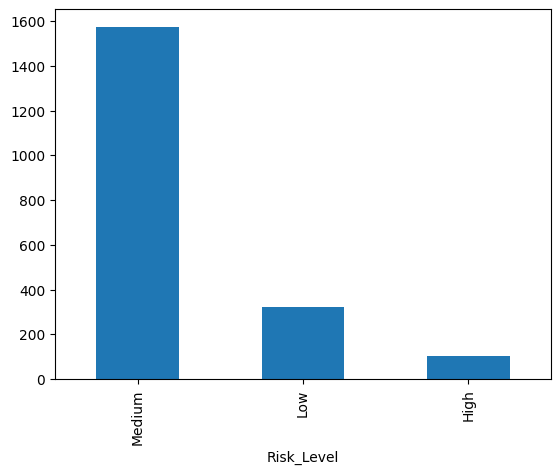

In [ ]:
df['Risk_Level'].value_counts().plot(kind='bar')

In [ ]:
df['Risk_Level'].value_counts() / len(df['Risk_Level']) * 100

,count
Risk_Level,
Medium,78.7
Low,16.2
High,5.1


## Risk Level bi imbalanced


In [ ]:
df.Gender.value_counts()

,count
Gender,
0,1022
1,978


<Axes: xlabel='Cancer_Type'>

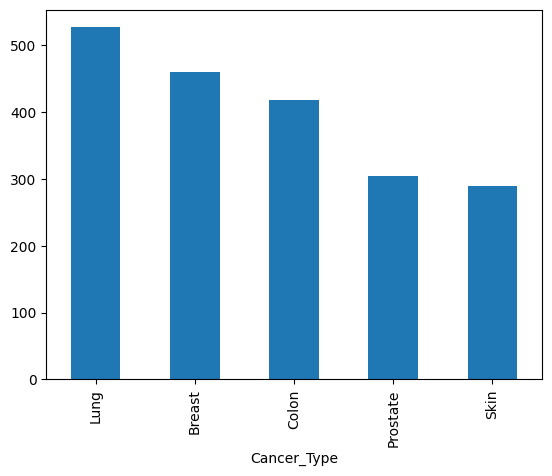

In [ ]:
df.Cancer_Type.value_counts().plot(kind='bar')

In [ ]:
gender_value_counts = df.groupby(['Gender', 'Cancer_Type']).size().reset_index(name='Count')

gender_value_counts['Gender'] = gender_value_counts['Gender'].map({0 : 'Female', 1 : 'Male'})

print(gender_value_counts)

   Gender Cancer_Type  Count
0  Female      Breast    455
1  Female       Colon    197
2  Female        Lung    238
3  Female        Skin    132
4    Male      Breast      5
5    Male       Colon    221
6    Male        Lung    289
7    Male    Prostate    305
8    Male        Skin    158


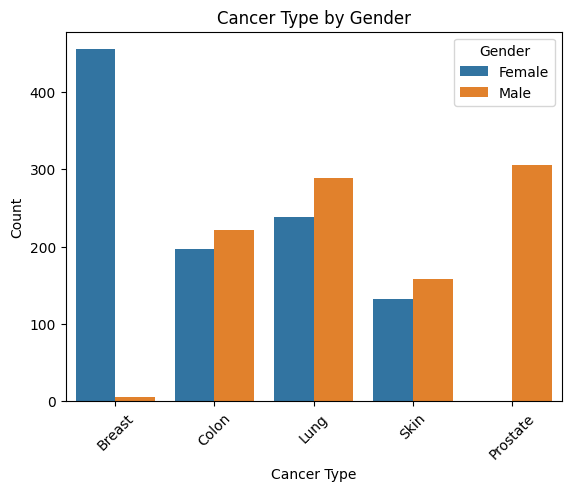

In [ ]:
sns.barplot(data=gender_value_counts, x='Cancer_Type', y ='Count', hue='Gender')
plt.title("Cancer Type by Gender")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
def age_group(age):
  if age <= 10:
    return '0-10'
  elif age <= 20:
    return '11-20'
  elif age <= 40:
    return '21-40'
  elif age <= 60:
    return '41-60'
  elif age <= 80:
    return '61-80'
  elif age <= 90:
    return '81-90'
  else:
    return '91+'

df_copy = df.copy()
df_age_cance_type = df_copy[['Age', 'Cancer_Type']]
df_age_cance_type['Age'] = df_age_cance_type['Age'].apply(age_group)

age_value_counts = df_age_cance_type.groupby(['Age', 'Cancer_Type']).size().reset_index(name='Count')

age_value_counts['Age'] = age_value_counts['Age'].map({
    '0-10' : 0,
    '11-20' : 1,
    '21-40' : 2,
    '41-60' : 3,
    '61-80' : 4,
    '81-90' : 5,
    '91+' : 6
})
print(age_value_counts)

    Age Cancer_Type  Count
0     2      Breast     19
1     2       Colon      5
2     2        Lung     13
3     2        Skin      3
4     3      Breast    172
5     3       Colon    182
6     3        Lung    206
7     3    Prostate     36
8     3        Skin    124
9     4      Breast    263
10    4       Colon    221
11    4        Lung    304
12    4    Prostate    203
13    4        Skin    158
14    5      Breast      6
15    5       Colon     10
16    5        Lung      4
17    5    Prostate     66
18    5        Skin      5


/tmp/ipykernel_30156/3830094564.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age_cance_type['Age'] = df_age_cance_type['Age'].apply(age_group)


[]

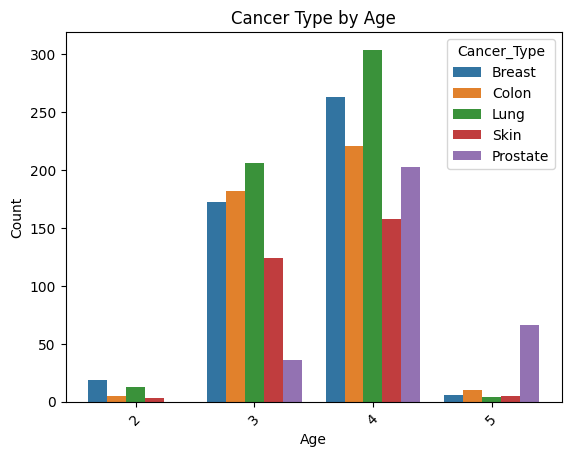

In [ ]:
sns.barplot(data=age_value_counts, x='Age', y ='Count', hue='Cancer_Type')
plt.title("Cancer Type by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.plot()

<Axes: xlabel='Risk_Level'>

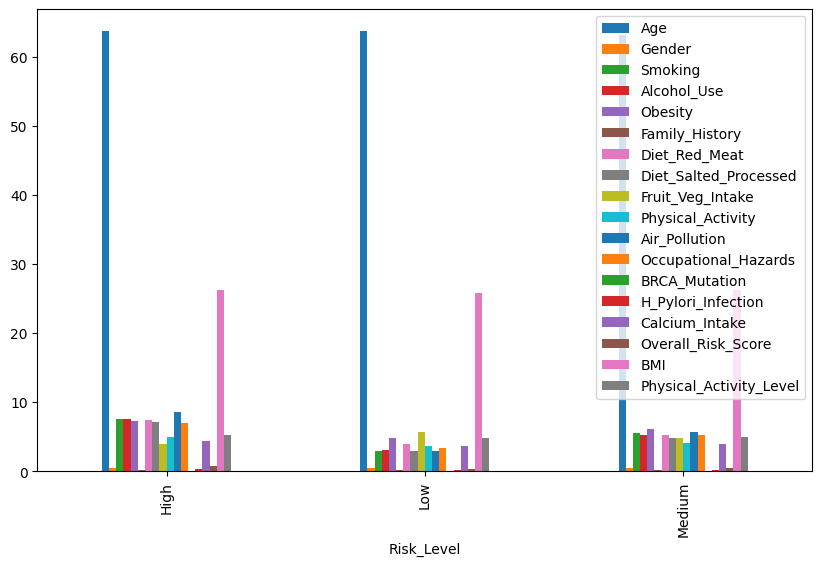

In [ ]:
numeric_columns = df.select_dtypes(include=['number']).columns

risk_means = df.groupby('Risk_Level')[numeric_columns].mean()

risk_means.plot(kind='bar', figsize=(10, 6))

In [ ]:
numeric_columns = df.select_dtypes(include=['number']).columns

risk_means = df.groupby('Risk_Level')[numeric_columns].mean().T

print(risk_means)

Risk_Level                    High        Low     Medium
Age                      63.745098  63.685185  63.125794
Gender                    0.509804   0.493827   0.486658
Smoking                   7.519608   2.845679   5.479670
Alcohol_Use               7.519608   2.984568   5.296061
Obesity                   7.274510   4.824074   6.118170
Family_History            0.205882   0.138889   0.205210
Diet_Red_Meat             7.362745   3.972222   5.299238
Diet_Salted_Processed     7.039216   2.888889   4.747776
Fruit_Veg_Intake          3.911765   5.666667   4.841169
Physical_Activity         4.921569   3.669753   4.027319
Air_Pollution             8.539216   2.947531   5.603558
Occupational_Hazards      6.990196   3.364198   5.181067
BRCA_Mutation             0.049020   0.037037   0.030496
H_Pylori_Infection        0.245098   0.175926   0.197586
Calcium_Intake            4.323529   3.651235   3.975222
Overall_Risk_Score        0.699991   0.269458   0.476616
BMI                      26.225

### Các thông tin chi tiết (Insights) quan trọng từ bảng phân tích `risk_means`

Dưới đây là những phân tích chi tiết và các phát hiện quan trọng khi so sánh giá trị trung bình của các yếu tố rủi ro giữa 3 nhóm nguy cơ (**High** - Cao, **Medium** - Trung bình, và **Low** - Thấp):

#### 1. Sự khác biệt rõ rệt từ các thói quen sinh hoạt hại sức khỏe
* **Hút thuốc (Smoking) & Sử dụng rượu bia (Alcohol_Use):** Hai yếu tố này có sự phân hóa cực kỳ rõ ràng. Ở nhóm nguy cơ cao (**High**), điểm số trung bình cho cả hai thói quen này đều đạt mức rất cao (~7.52). Trong khi đó, ở nhóm nguy cơ thấp (**Low**), điểm số này chỉ dao động dưới mức 3.0. Nhóm trung bình nằm ở khoảng giữa (~5.3 - 5.5).
* **Béo phì (Obesity) & Chỉ số khối cơ thể (BMI):** Nhóm nguy cơ cao có mức độ béo phì trung bình là 7.27 so với nhóm nguy cơ thấp là 4.82. Thú vị là chỉ số BMI trung bình giữa các nhóm không có sự chênh lệch quá lớn (đều dao động quanh ngưỡng 25.8 - 26.2), cho thấy điểm đánh giá mức độ béo phì cụ thể có mối liên hệ chặt chẽ với mức độ nguy cơ hơn là chỉ số BMI đơn thuần.

#### 2. Tác động từ chế độ dinh dưỡng
* **Thịt đỏ (Diet_Red_Meat) & Thực phẩm chế biến sẵn/ướp muối (Diet_Salted_Processed):** Việc tiêu thụ nhiều thịt đỏ (~7.36) và đồ ăn mặn/chế biến sẵn (~7.04) liên quan trực tiếp đến nhóm nguy cơ cao. Ngược lại, nhóm nguy cơ thấp tiêu thụ các loại thực phẩm này ít hơn hẳn (~3.97 và ~2.89).
* **Tiêu thụ rau củ quả (Fruit_Veg_Intake):** Đây là một yếu tố bảo vệ. Nhóm nguy cơ thấp có chỉ số tiêu thụ rau quả cao nhất (~5.67), giảm dần ở nhóm nguy cơ trung bình (~4.84) và thấp nhất ở nhóm nguy cơ cao (~3.91).

#### 3. Tác động cực kỳ mạnh mẽ từ môi trường và nghề nghiệp
* **Ô nhiễm không khí (Air_Pollution):** Đây là một trong những cột có sự chênh lệch điểm số lớn nhất. Nhóm nguy cơ cao có điểm số tiếp xúc ô nhiễm trung bình lên tới **8.54**, trong khi nhóm nguy cơ thấp chỉ là **2.95**. Điều này chỉ ra ô nhiễm không khí là một tác nhân môi trường cực kỳ nguy hiểm liên quan đến ung thư.
* **Nguy cơ nghề nghiệp (Occupational_Hazards):** Tương tự như ô nhiễm, nhóm nguy cơ cao tiếp xúc với các mối nguy hại tại nơi làm việc nhiều hơn gấp đôi so với nhóm nguy cơ thấp (6.99 so với 3.36).

#### 4. Các yếu tố ít hoặc không có sự khác biệt lớn
* **Tuổi tác (Age):** Độ tuổi trung bình ở cả 3 nhóm nguy cơ gần như bằng nhau (~63 tuổi). Điều này cho thấy trong tập dữ liệu này, tuổi tác đơn thuần không phải là yếu tố phân loại mức độ nguy cơ rủi ro tổng thể.
* **Giới tính (Gender):** Tỷ lệ giới tính phân bổ khá đồng đều ở cả 3 nhóm (xoay quanh mức ~0.48 - 0.51, tức là tỉ lệ nam/nữ xấp xỉ 50/50).
* **Gen di truyền và Nhiễm khuẩn (BRCA_Mutation & H_Pylori_Infection):** Tỷ lệ đột biến gen BRCA và nhiễm vi khuẩn HP có xu hướng cao hơn một chút ở nhóm nguy cơ cao nhưng sự chênh lệch không quá đột biến như các yếu tố hành vi và môi trường.

#### 📌 Tóm lại:
Nguy cơ ung thư cao (**High Risk**) trong tập dữ liệu này bị ảnh hưởng mạnh nhất bởi **Ô nhiễm không khí**, **Nguy cơ nghề nghiệp**, **Hút thuốc**, **Uống rượu bia**, và **Chế độ ăn nhiều thịt đỏ/đồ chế biến sẵn**. Ngược lại, lối sống lành mạnh với **nhiều rau xanh/trái cây** và **ít chất kích thích** là những đặc trưng nổi bật của nhóm nguy cơ thấp (**Low Risk**).

In [ ]:
risk_difference = risk_means['High'] - risk_means['Low']
# risk_difference = risk_difference[((risk_difference <= -1) | (risk_difference >= 1))]

risk_difference = risk_difference.sort_values(ascending=False)

print(risk_difference)

Air_Pollution              5.591685
Smoking                    4.673929
Alcohol_Use                4.535040
Diet_Salted_Processed      4.150327
Occupational_Hazards       3.625999
Diet_Red_Meat              3.390523
Obesity                    2.450436
Physical_Activity          1.251816
Calcium_Intake             0.672295
Overall_Risk_Score         0.430533
BMI                        0.410984
Physical_Activity_Level    0.337509
H_Pylori_Infection         0.069172
Family_History             0.066993
Age                        0.059913
Gender                     0.015977
BRCA_Mutation              0.011983
Fruit_Veg_Intake          -1.754902
dtype: float64


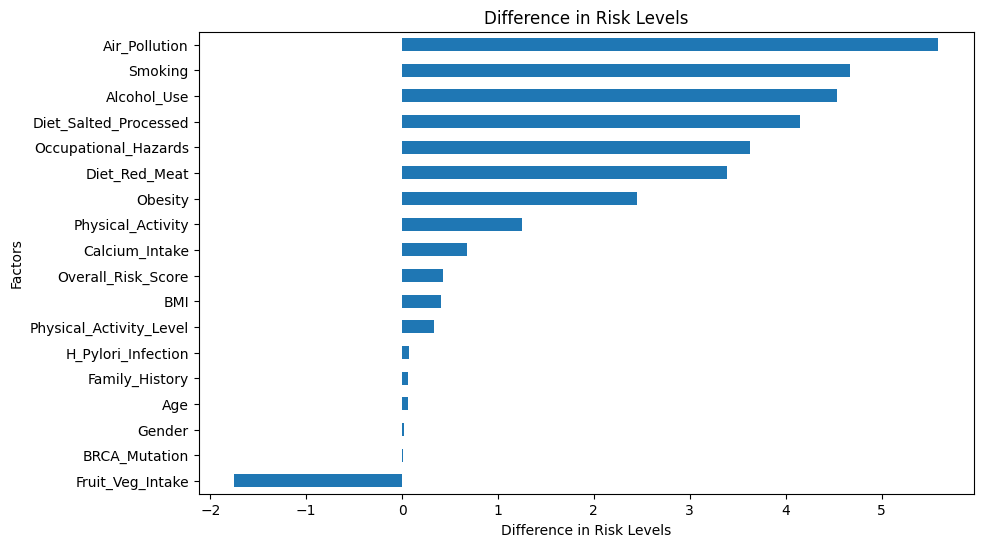

In [ ]:
risk_difference.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), title='Difference in Risk Levels')
plt.xlabel('Difference in Risk Levels')
plt.ylabel('Factors')
plt.show()

## Univariate

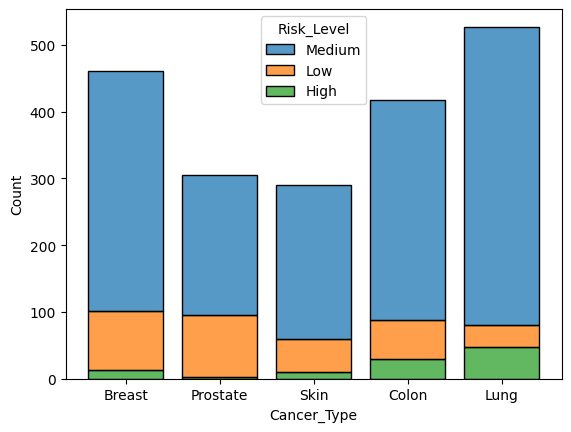

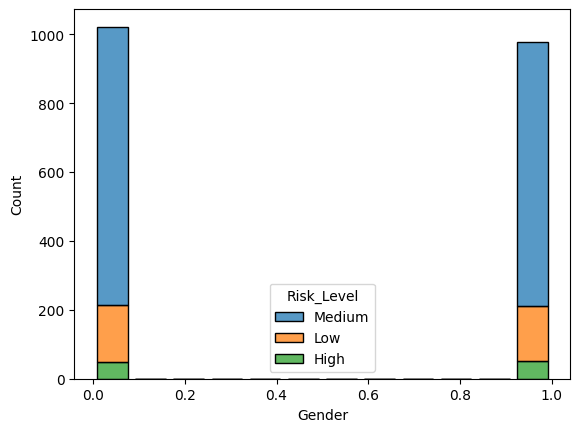

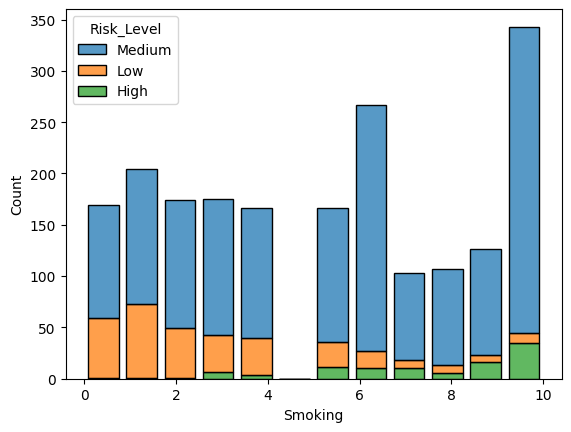

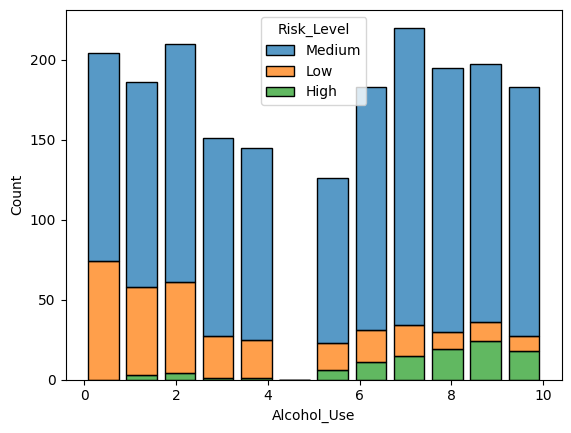

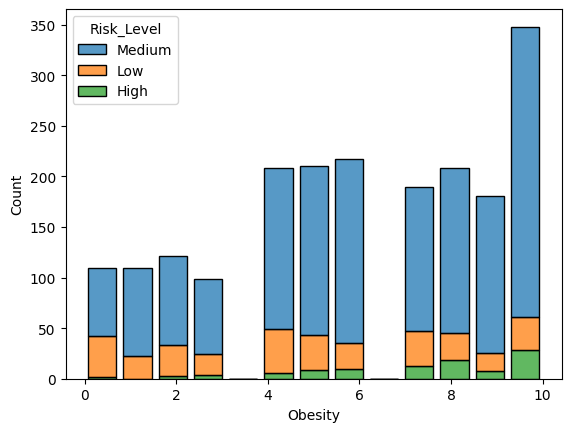

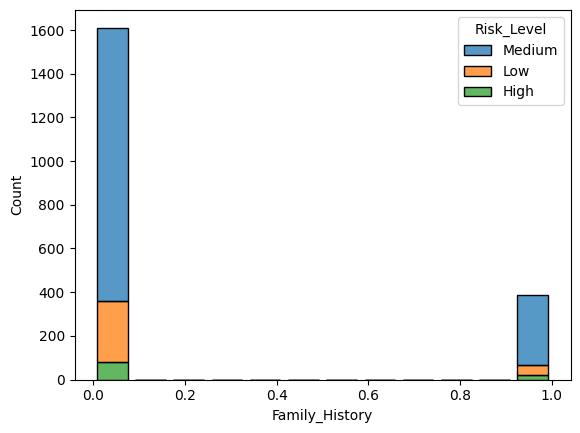

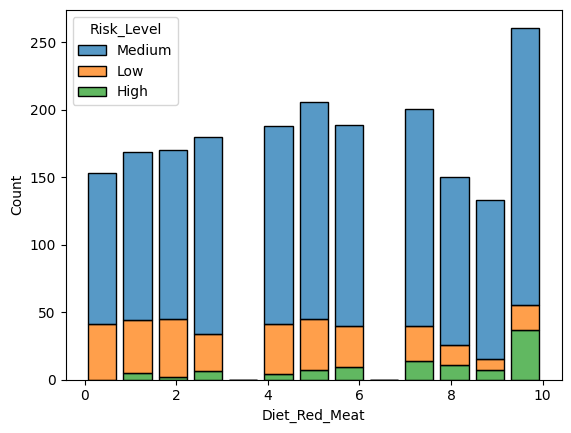

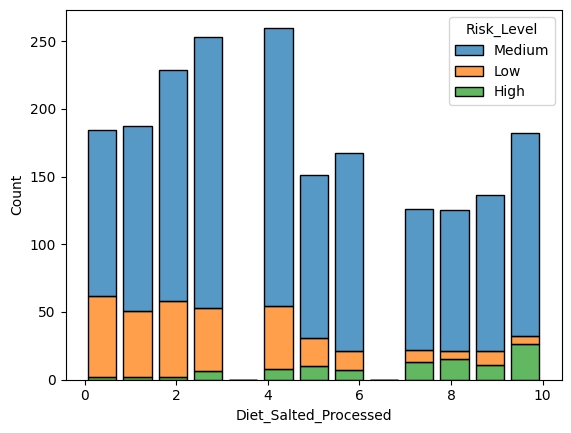

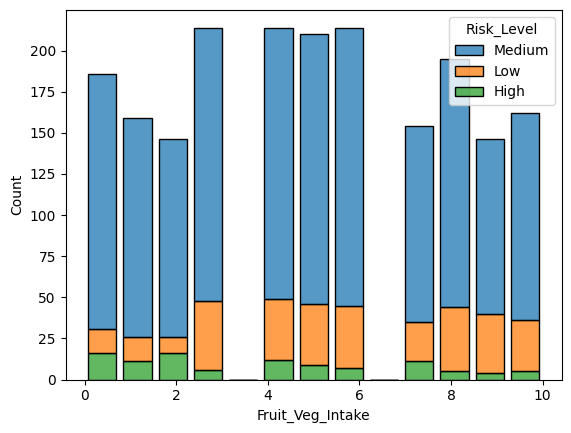

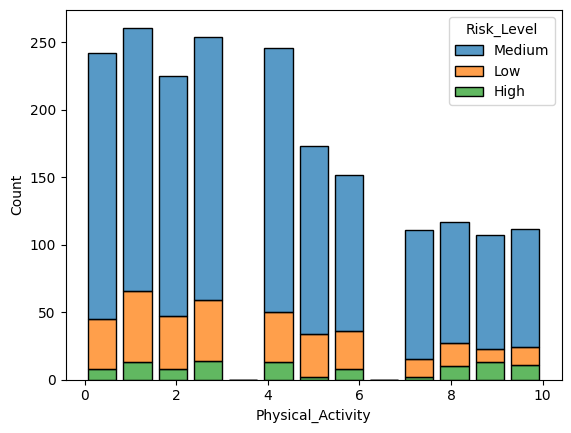

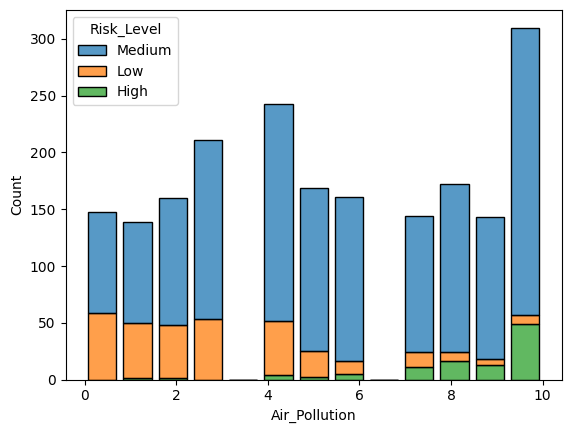

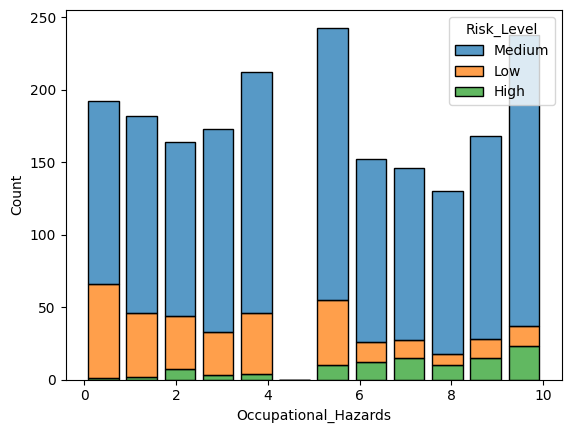

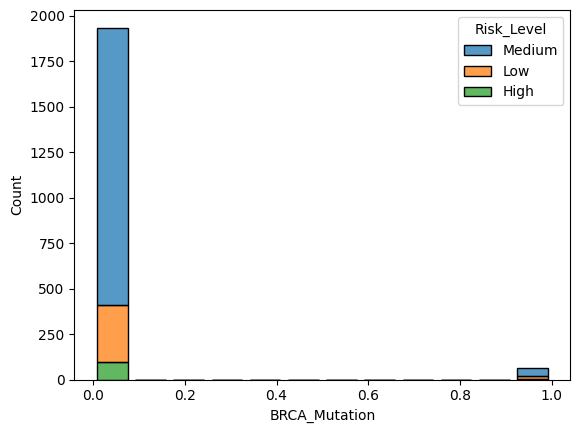

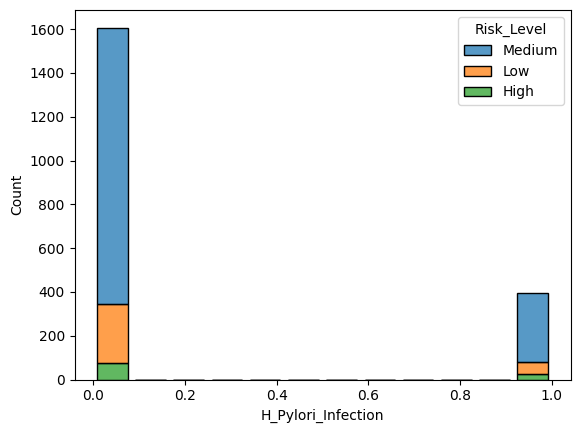

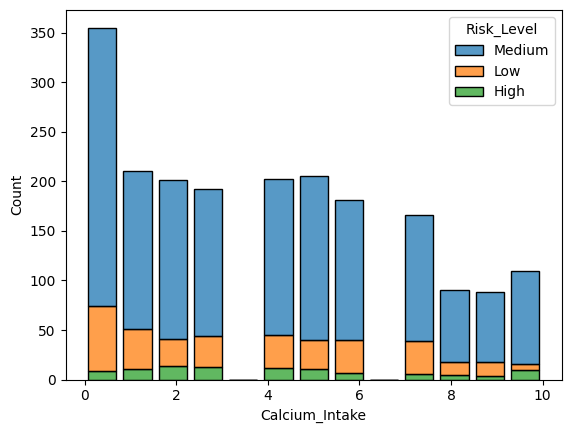

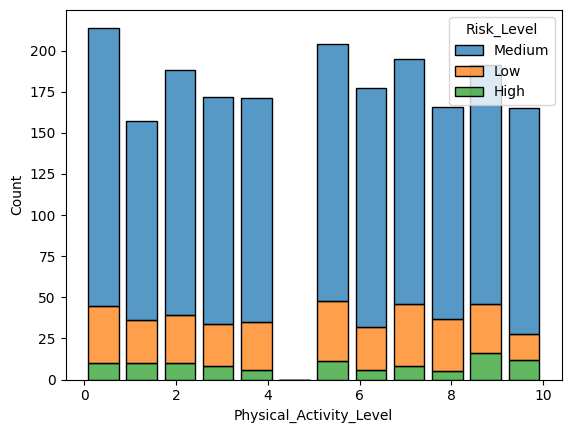

In [ ]:
for i, predictor in enumerate(df.drop(columns=['Patient_ID', 'Risk_Level', 'Age', 'Overall_Risk_Score', 'BMI'])):
  plt.figure(i)
  sns.histplot(data=df, x=predictor, hue='Risk_Level', multiple='stack', shrink=.8)

In [ ]:
df['Risk_Level'].value_counts() / len(df['Risk_Level']) * 100

,count
Risk_Level,
Medium,78.7
Low,16.2
High,5.1


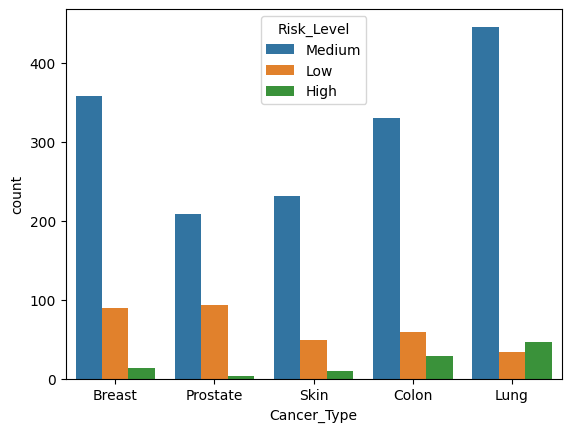

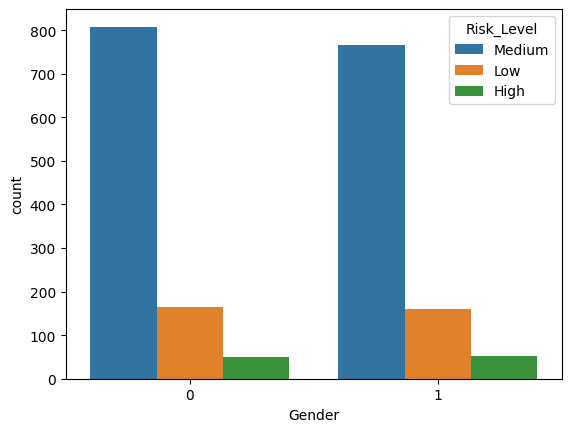

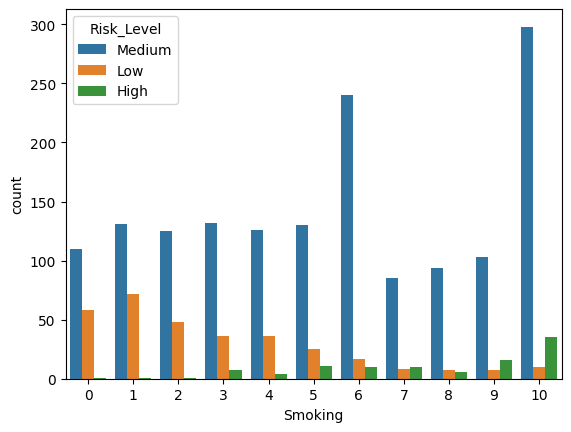

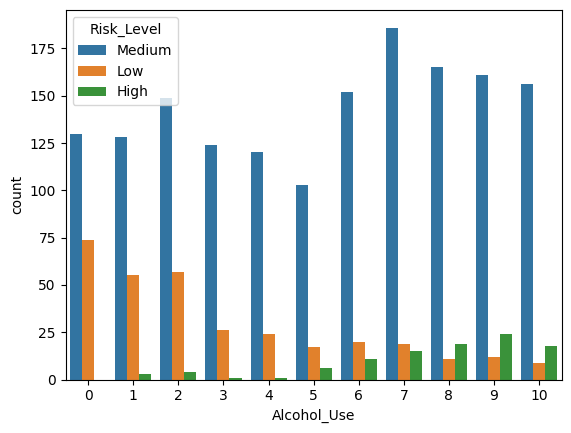

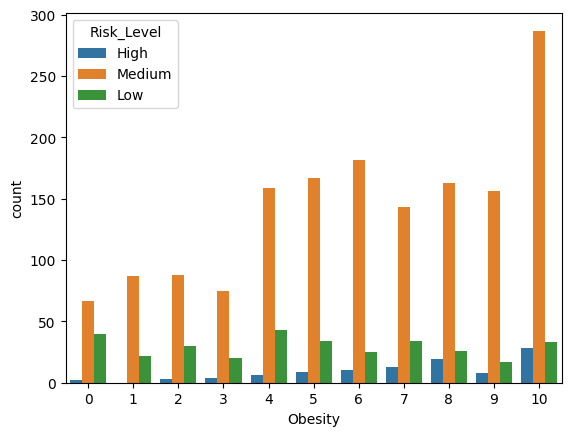

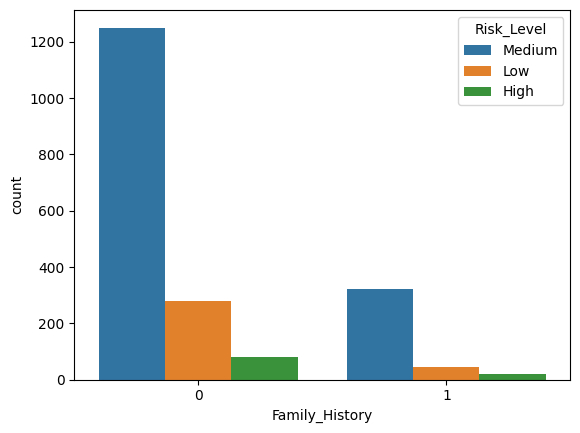

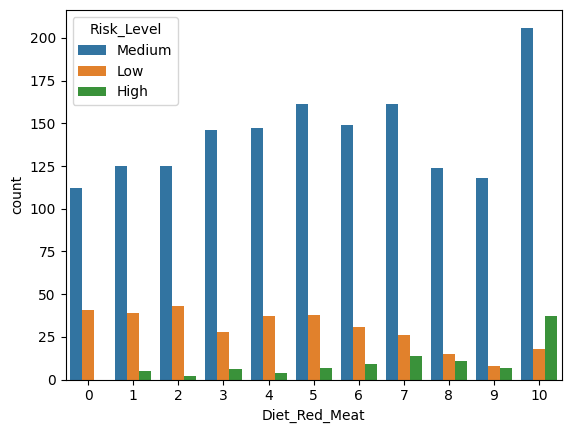

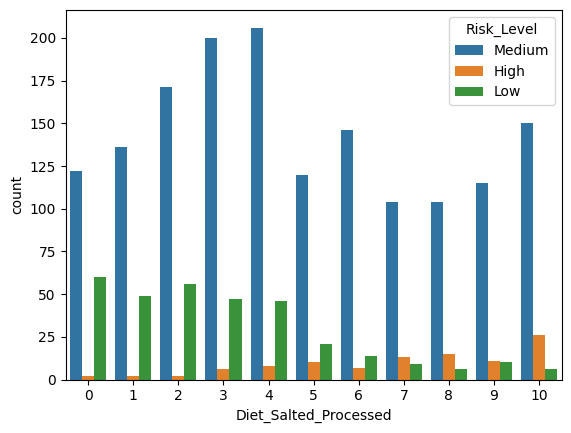

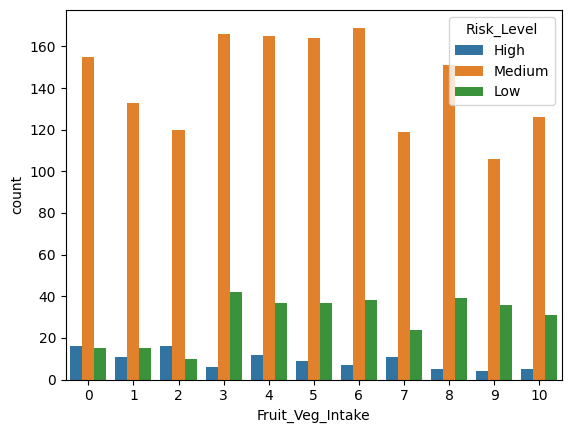

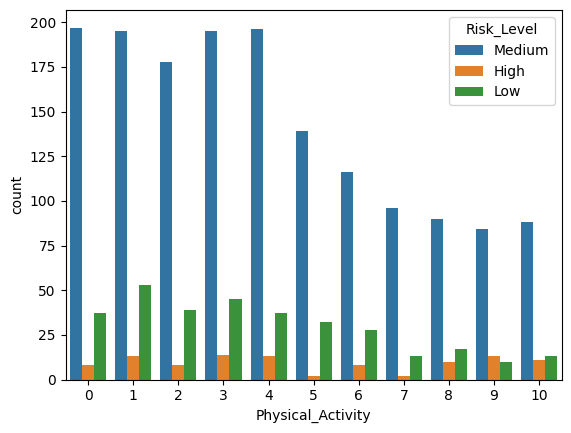

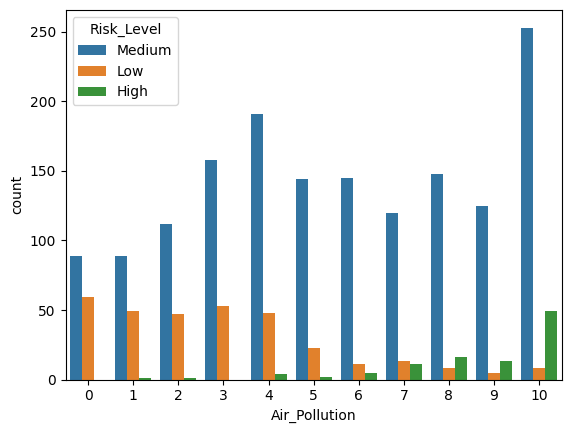

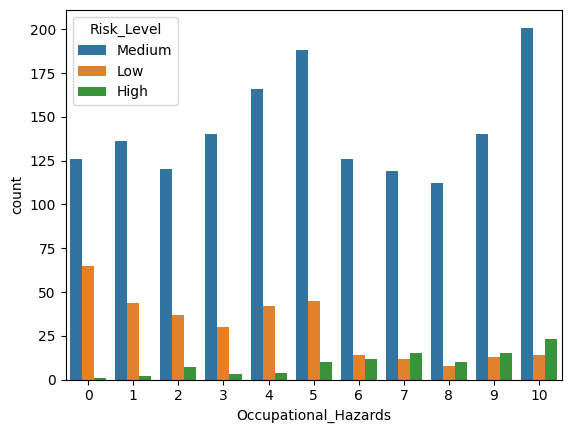

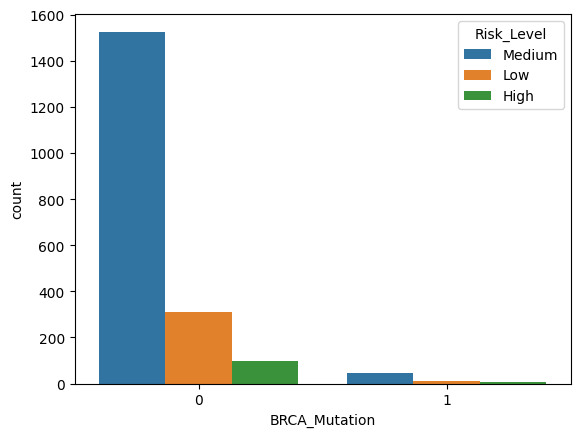

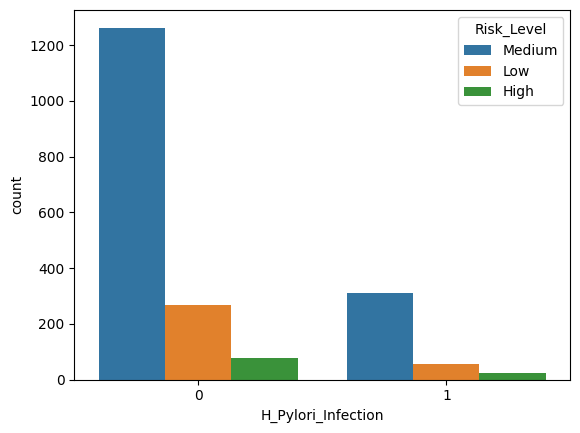

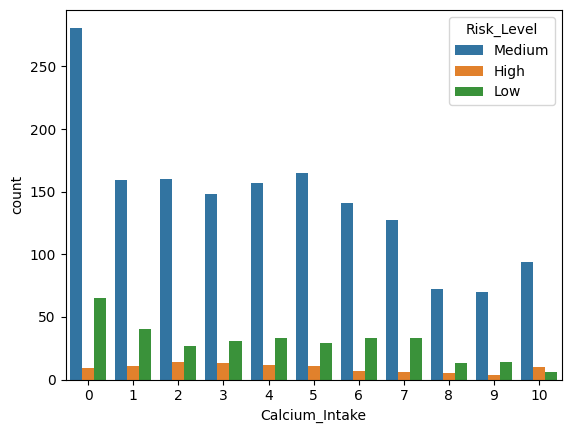

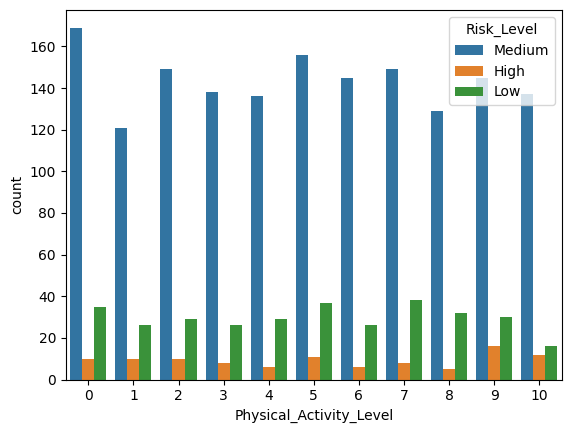

In [ ]:
for i, predictor in enumerate(df.drop(columns=['Patient_ID', 'Risk_Level', 'Age', 'Overall_Risk_Score', 'BMI'])):
  plt.figure(i)
  sns.countplot(data=df, x=predictor, hue='Risk_Level')

In [ ]:
df = df.drop(columns=['Patient_ID', 'Age', 'Overall_Risk_Score', 'BMI'])

In [ ]:
# Đọc lại dữ liệu gốc để khôi phục cột Risk_Level bị NaN
df = pd.read_csv('/content/cancer-risk-factors.csv')
df = df.drop(columns=['Patient_ID', 'Age', 'Overall_Risk_Score', 'BMI'])

# Ánh xạ an toàn (sử dụng .replace hoặc kiểm tra kiểu dữ liệu để không bị lỗi khi chạy lại)
df['Risk_Level'] = df['Risk_Level'].replace({
    'Low' : 0,
    'Medium' : 1,
    'High' : 2
})

/tmp/ipykernel_30156/4163708368.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Risk_Level'] = df['Risk_Level'].replace({


In [ ]:
df_dummies = pd.get_dummies(df)
df_dummies.head(5).T

,0,1,2,3,4
Gender,0,1,1,0,1
Smoking,7,8,7,6,10
Alcohol_Use,2,9,10,2,7
Obesity,8,8,7,2,4
Family_History,0,0,0,0,0
Diet_Red_Meat,5,0,3,6,6
Diet_Salted_Processed,3,3,3,2,3
Fruit_Veg_Intake,7,7,4,4,10
Physical_Activity,4,1,1,6,9
Air_Pollution,6,3,8,4,10


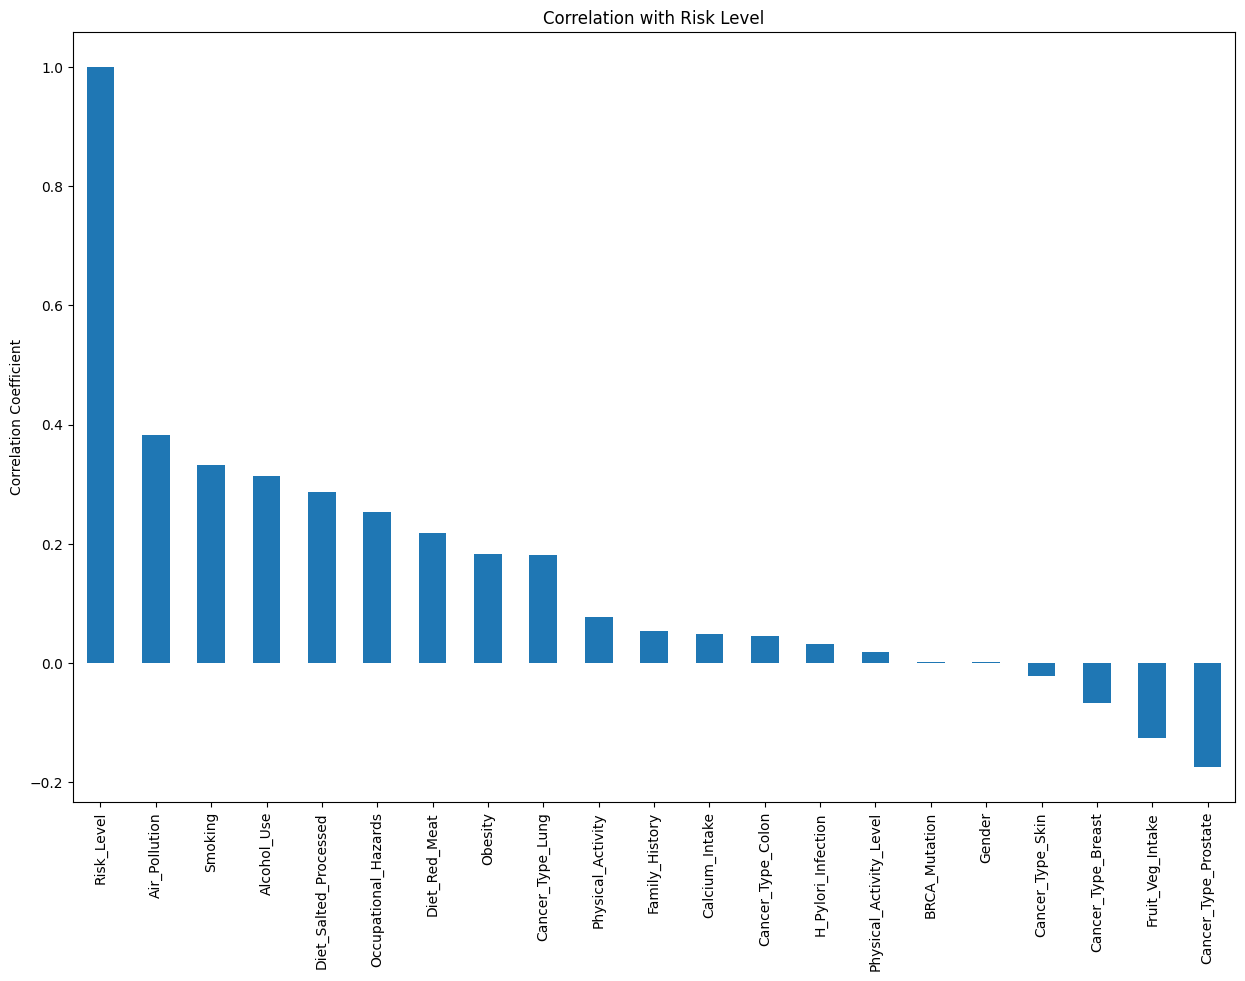

In [ ]:
# Tạo các cột dummy
df_dummies = pd.get_dummies(df)

# Vẽ biểu đồ tương quan
plt.figure(figsize=(15, 10))
df_dummies.corr()['Risk_Level'].sort_values(ascending=False).plot(kind='bar')
plt.title("Correlation with Risk Level")
plt.ylabel("Correlation Coefficient")
plt.show()